In [1]:
# for datasets in sim 3- counts are generated so that the ratios are close the real data noise level 2 

In [ ]:
# # Order of correlations: [rho_alpha_beta, rho_alpha_nu, rho_alpha_gamma, rho_beta_nu, rho_beta_gamma, rho_nu_gamma]
# # Order of sigmas : [sigma_log_alpha, sigma_log_beta, sigma_log_nu, sigma_log_gamma]
# # Order of means : [alpha,beta,nu,gamma]

# config_simulation = {'parameters':{ 'n_obs':1000,
#     'n_vars':400,
#     'alpha':None,
#     'beta':None,
#     'nu' :None,
#     'gamma':None,
#     'alpha_':0,
#     't_max':30,
#     'noise_model':"normal",
#     'noise_level':2,
#     }, 

#     'options': {'generate_parameters':True,
#                 'generate_switch_times':True,
#                   'save':False,
#                   'saving_path':None
#                   },
#     'coeff_generate_options':{ 
#     'corr':[0.1, 0.1, -0.1, 0.1, -0.1, -0.1],
#     'sd':[0.6, 0.6, 0.6, 0.6],
#     'mean':[np.log(5), np.log(0.02), np.log(0.34), np.log(0.33)]} }

# config_preprocessing = {'preprocess_params': {
#      'min_counts': 200, 
#      'min_cells': 5,
#      'n_neighbors': 15,
#      'n_pcs': 0,
#      'min_dist': 0.5,
#      'resolution':1},
# 'functions_to_apply': {'filter_cells': True, 
#                        'filter_genes': True, 
#                        'normalize_total': True,
#                        'log1p': True,
#                        'pca': True,
#                        'neighbors': True,
#                        'umap': True,
#                        'leiden': True,
#                        'moments': True}}


# # config_velocity = { 'velocity_types': ['dynamical','deterministic','stochastic','velovi']}
# config_velocity = { 'velocity_types': ['deterministic','stochastic','dynamical','velovi'],
#                    'velovi_model_params':{'n_hidden':256,
#                                     'n_latent':10,
#                                     'n_layers':1,
#                                     },
#                     'velovi_train_params': {'epochs':600,
#                                             'lr':0.01,
#                                             'weight_decay':0.01,
#                                             'early_stop':True,
#                                             'batch_size':256},
#                      'velovi_getting_parameters':{'t_max' :30 ,
#                                            'n_samples':25}}



In [1]:
import os
from pathlib import Path
import sys
import numpy as np
import scvelo as scv

In [2]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\nu_beta_effects'

In [3]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [4]:
os.chdir(Path(notebook_dir).parents[3])

In [5]:
stvelo_path = os.path.join(os.getcwd(),'STVelo','stvelo')

import sys  
sys.path.insert(1,stvelo_path)

from pipelines.metrics import *
from pipelines.utils import proportions_nuc_cyto

# Read adatas 

In [6]:
adata_folder_path = os.path.join(os.getcwd(), 'data', 'beta_small_22') 

In [7]:
import os
import anndata as ad


# Initialize an empty dictionary to store the AnnData objects
adata_dict = {}

# Loop through all files in the folder
for file_name in os.listdir(adata_folder_path):
    # Check if the file has .h5ad extension
    if file_name.endswith('.h5ad'):
        # Remove the file extension to use as the dictionary key
        key = os.path.splitext(file_name)[0]
        
        # Read the .h5ad file and store it in the dictionary
        adata_dict[key] = scv.read(os.path.join(adata_folder_path, file_name))

# Now, adata_dict contains the .h5ad files with keys as their filenames without extension


In [11]:
adatas = {k:v.copy() for k,v in adata_dict.items()}

In [12]:
import matplotlib.pyplot as plt 

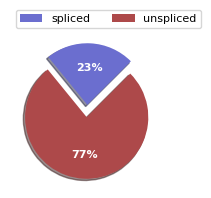

In [13]:
scv.pl.proportions(adata_dict['adata_s_u_1000obs_400genes_deterministic'],fontsize=8)

<Axes: >

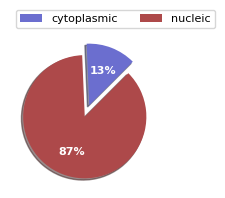

In [14]:
proportions_nuc_cyto(adata_dict['adata_n_c_1000obs_400genes_deterministic'])

In [15]:
unspliced = np.sum(adata_dict['adata_s_u_1000obs_400genes_dynamical'].layers['unspliced'])
spliced_nucleic = np.sum(adata_dict['adata_s_u_1000obs_400genes_dynamical'].layers['spliced_cyt'])
spliced_cytoplasmic = np.sum(adata_dict['adata_s_u_1000obs_400genes_dynamical'].layers['spliced_nuc'])

In [16]:
import matplotlib.pyplot as plt
import scvelo as scv

def plot_velocity_embedding_streams(adata_dict, n_obs=1000, n_var=400, color_option='true_t'):
    """
    Plots velocity embedding streams for an AnnData dictionary with a specified color option.

    Parameters:
    - adata_dict (dict): Dictionary with AnnData objects. Keys should follow the pattern 
                         'adata_s_u_800obs_300genes_{velocity_type}' and 
                         'adata_n_c_800obs_300genes_{velocity_type}'.
    - color_option (str): Column name in AnnData.obs to color the plots. Default is 'true_t'.
    """
    # Create a figure with 2 rows and 4 columns of subplots
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))  # Adjust figsize for better visibility

    # List of velocity types and corresponding column labels
    velocity_types = ['deterministic', 'stochastic', 'dynamical', 'velovi']
    column_labels = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']

    # Row titles
    row_titles = ['Unspliced - Spliced', 'Cytoplasmic - Nucleic']

    # Adjust subplot parameters to make room for column headings
    plt.subplots_adjust(top=0.90, left=0.10)

    # Loop over each data type and plot the corresponding subplots
    for i, (data_type, row_title) in enumerate(zip(['s_u', 'n_c'], row_titles)):
        for j, (velocity_type, col_label) in enumerate(zip(velocity_types, column_labels)):
            # Plotting
            adata_key = f'adata_{data_type}_{n_obs}obs_{n_var}genes_{velocity_type}'
            if adata_key in adata_dict:
                scv.pl.velocity_embedding_stream(
                    adata_dict[adata_key],
                    basis='umap',
                    color=color_option,
                    ax=axes[i, j],
                    show=False,
                    title=''
                )
            else:
                axes[i, j].axis('off')  # If the adata is not available, turn off the axis

            # Turn off axis labels to reduce clutter
            axes[i, j].set_xlabel('')
            axes[i, j].set_ylabel('')

    # Add column titles (velocity models)
    for j, col_label in enumerate(column_labels):
        axes[0, j].set_title(col_label, fontsize=16)

    # Add row titles (data types)
    for i, row_title in enumerate(row_titles):
        # Place text in the middle of the row
        fig.text(
            0.04,  # Adjust as needed for horizontal position
            (0.72 - i * 0.44),  # Adjust for vertical position
            row_title,
            ha='center',
            va='center',
            rotation='vertical',
            fontsize=16
        )

    # Adjust layout to prevent overlap
    plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])

    # Show the plot
    plt.show()


In [19]:
scv.tl.velocity_graph(adata_dict['adata_s_u_1000obs_400genes_deterministic'],vkey='true_velocity')

computing velocity graph (using 1/24 cores)
    finished (0:00:00) --> added 
    'true_velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [17]:
scv.tl.velocity_graph(adata_dict['adata_n_c_1000obs_400genes_deterministic'],vkey='true_velocity')

computing velocity graph (using 1/24 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:00:00) --> added 
    'true_velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


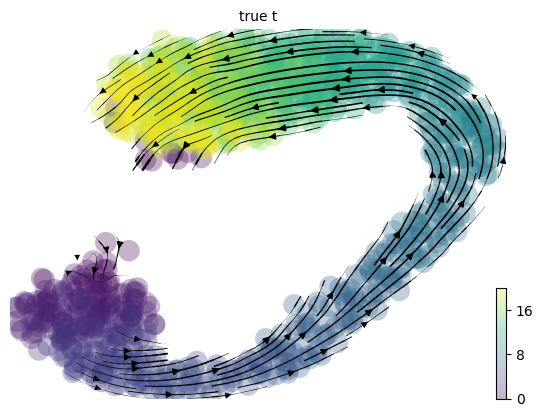

In [18]:
scv.pl.velocity_embedding_stream(adata_dict['adata_n_c_1000obs_400genes_deterministic'],vkey='velocity',color='true_t')

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


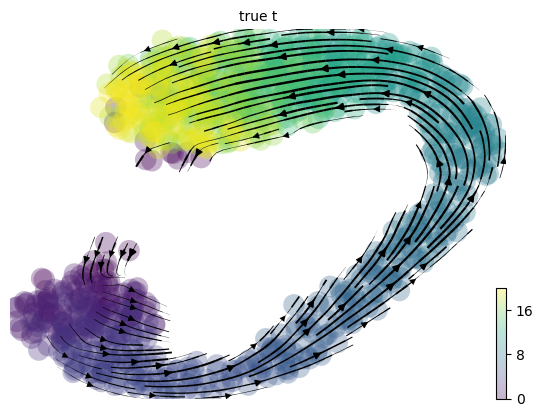

In [20]:
scv.pl.velocity_embedding_stream(adata_dict['adata_s_u_1000obs_400genes_deterministic'],vkey='velocity',color='true_t')

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


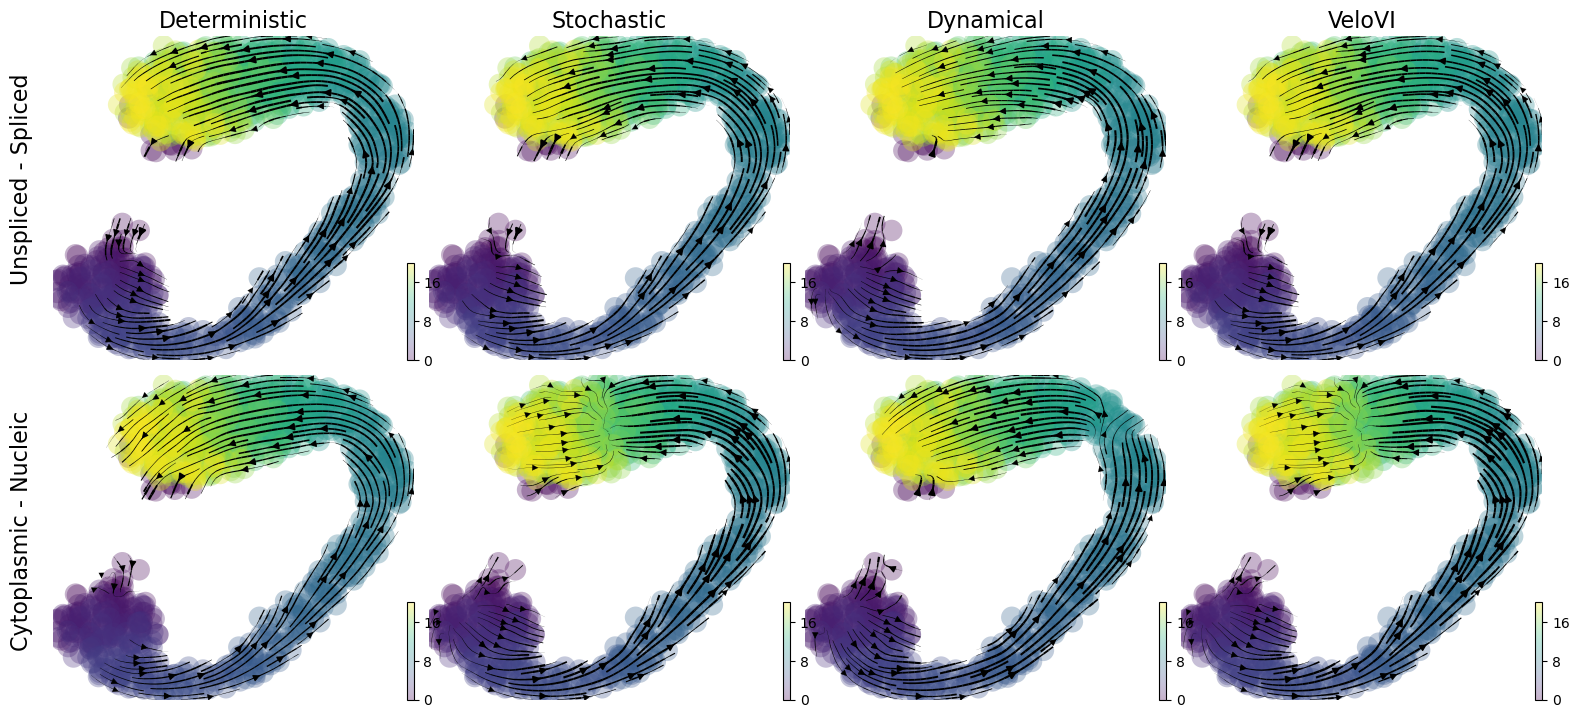

In [21]:
plot_velocity_embedding_streams(adata_dict=adata_dict)

# Metrics 

# Confidence 

- Confidence metric measures the mean velocity consistency by calculating the pearson correlation between a cell and its neighbours. Let $v(x_j)$ be the velocity of cell $x_j$. Confidence $c_j$ is given by;

$$c_j = \frac{1}{k} \sum_{x \in \mathit{N_k(x_j)} } corr(v(x_j),v(x))$$

where $\mathit{N_k(x_j)}$ is the k-neighbours of $x_j$ in KNN graph.


sc.pp.neighbors(adata) > scv.tl.velocity() > scv.tl.velocity_graph() to compute cosine corr. > scv.tl.velocity_confidence()

In [22]:
import scvelo as scv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_velocity_confidences(adatas):
    """
    Computes velocity confidences for each AnnData object in the dictionary and plots them using a violin plot.

    Parameters:
    - adatas (dict): Dictionary where keys are in the format 'adata_type_obs_genes_velocitytype', 
                     and values are AnnData objects.

    The keys should follow this format:
    - 'adata_n_c_800obs_300genes_deterministic' or
      'adata_s_u_800obs_300genes_deterministic'
    """
    
    # Initialize an empty list to collect data for plotting
    plot_data = []

    # Loop through each AnnData object in the dictionary
    for key, adata in adatas.items():
        # Compute velocity confidence
        scv.tl.velocity_confidence(adata)

        # Extract velocity confidences from adata.obs
        velocity_confidence = adata.obs['velocity_confidence'].values
        velocity_length = adata.obs['velocity_length'].values
        velocity_confidence_transition = adata.obs['velocity_confidence_transition'].values

        # Parse the key to extract metadata
        # Key format: 'adata_n_c_800obs_300genes_deterministic'
        parts = key.split('_')
        data_type = parts[1] + '_' + parts[2]  # e.g., 'n_c' or 's_u'
        obs_count = parts[3]  # e.g., '800obs'
        gene_count = parts[4]  # e.g., '300genes'
        velocity_type = parts[-1]  # e.g., 'deterministic', 'stochastic', 'dynamical', 'velovi'

        # Map data_type to full names
        data_type_map = {'n_c': 'cytoplasmic-nucleic', 's_u': 'spliced-unspliced'}
        data_type_full = data_type_map.get(data_type, data_type)

        # Map velocity_type to capitalized labels
        velocity_type_map = {
            'deterministic': 'Deterministic',
            'stochastic': 'Stochastic',
            'dynamical': 'Dynamical',
            'velovi': 'VeloVI'
        }
        velocity_type_label = velocity_type_map.get(velocity_type, velocity_type.capitalize())

        # Create a DataFrame for this adata
        df = pd.DataFrame({
            'velocity_confidence': velocity_confidence,
            'velocity_length': velocity_length,
            'velocity_confidence_transition': velocity_confidence_transition,
            'data_type': data_type_full,
            'obs_count': obs_count,
            'gene_count': gene_count,
            'velocity_type': velocity_type,
            'velocity_type_label': velocity_type_label
        })

        # Append to the list
        plot_data.append(df)

    # Concatenate all DataFrames into one
    plot_df = pd.concat(plot_data, ignore_index=True)

    # Define the order of velocity types
    velocity_type_order = ['deterministic', 'stochastic', 'dynamical', 'velovi']
    # Corresponding labels
    velocity_type_labels = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']
    # Map velocity_type to labels
    velocity_type_label_map = dict(zip(velocity_type_order, velocity_type_labels))

    # Map velocity_type to categorical type with specified order
    plot_df['velocity_type'] = pd.Categorical(
        plot_df['velocity_type'],
        categories=velocity_type_order,
        ordered=True
    )
    # Ensure the labels are in the same order
    plot_df['velocity_type_label'] = pd.Categorical(
        plot_df['velocity_type_label'],
        categories=velocity_type_labels,
        ordered=True
    )

    # Now, plot using seaborn
    # sns.set(style="whitegrid")

    # Create a color palette for data types
    data_types = plot_df['data_type'].unique()
    # Specify colors you want to use
    custom_palette = ['#1f77b4', '#ff7f0e']  # Example colors: blue and orange
    palette_dict = dict(zip(data_types, custom_palette))

    # Plot the violin plot
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.violinplot(
        x='velocity_type_label', 
        y='velocity_confidence', 
        hue='data_type', 
        data=plot_df, 
        palette=palette_dict, 
        split=False,
        scale='width',
        # inner='quartile',
        order=velocity_type_labels,
        ax=ax
    )

    # Add vertical lines to separate velocity types
    x_positions = ax.get_xticks()
    for x in x_positions[1:]:
        ax.axvline(x=x - 0.5, color='gray', linestyle='--', linewidth=1)

    # Adjust legend labels
    handles, labels = ax.get_legend_handles_labels()
    # ax.legend(handles=handles, labels=labels, title='', bbox_to_anchor=(1.05, 1), loc='best')
    ax.legend(handles=handles, labels=labels, title='', loc='best')

    plt.title('Velocity Consistency')
    plt.xlabel('')
    plt.ylabel('')
    # plt.tight_layout()
    plt.show()


--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length'

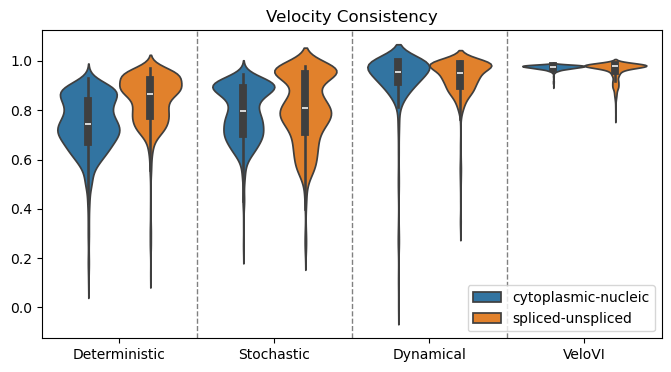

In [23]:
plot_velocity_confidences(adata_dict)

In [24]:
import numpy as np

def cosine_similarity_matrices(matrix1, matrix2, mode='by_row'):
    """
    Computes cosine similarity between two matrices either by row or by column.

    Parameters:
    - matrix1, matrix2: Two matrices (NumPy arrays or DataFrames) with the same shape.
    - mode: 'by_row' or 'by_column' to specify the direction for calculating similarities.

    Returns:
    - similarities: List of cosine similarity values for each row or column.
    """
    # Ensure matrices are NumPy arrays
    if isinstance(matrix1, pd.DataFrame):
        matrix1 = matrix1.values
    if isinstance(matrix2, pd.DataFrame):
        matrix2 = matrix2.values

    # Check if shapes are compatible
    if matrix1.shape != matrix2.shape:
        raise ValueError("Both matrices must have the same shape.")

    # Initialize list to store similarity scores
    similarities = []

    # Cosine similarity by row (across columns)
    if mode == 'by_row':
        for i in range(matrix1.shape[0]):  # Loop through each row
            row1 = matrix1[i, :]
            row2 = matrix2[i, :]
            # Calculate cosine similarity, handling zero-vectors to avoid division by zero
            norm1 = np.linalg.norm(row1)
            norm2 = np.linalg.norm(row2)
            if norm1 > 0 and norm2 > 0:
                similarity = np.dot(row1, row2) / (norm1 * norm2)
            else:
                similarity = np.nan  # Set NaN if one of the rows is a zero vector
            similarities.append(similarity)

    # Cosine similarity by column (across rows)
    elif mode == 'by_column':
        for j in range(matrix1.shape[1]):  # Loop through each column
            col1 = matrix1[:, j]
            col2 = matrix2[:, j]
            # Calculate cosine similarity, handling zero-vectors to avoid division by zero
            norm1 = np.linalg.norm(col1)
            norm2 = np.linalg.norm(col2)
            if norm1 > 0 and norm2 > 0:
                similarity = np.dot(col1, col2) / (norm1 * norm2)
            else:
                similarity = np.nan  # Set NaN if one of the columns is a zero vector
            similarities.append(similarity)

    else:
        raise ValueError("Invalid mode. Use 'by_row' or 'by_column'.")

    return similarities


In [25]:
import numpy as np
import pandas as pd

def pearson_correlation_matrices(matrix1, matrix2, mode='by_row'):
    """
    Computes Pearson correlation between two matrices either by row or by column.

    Parameters:
    - matrix1, matrix2: Two matrices (NumPy arrays or DataFrames) with the same shape.
    - mode: 'by_row' or 'by_column' to specify the direction for calculating correlations.

    Returns:
    - correlations: List of Pearson correlation coefficients for each row or column.
    """
    # Ensure matrices are in the right shape and format (convert to numpy if DataFrame)
    if isinstance(matrix1, pd.DataFrame):
        matrix1 = matrix1.values
    if isinstance(matrix2, pd.DataFrame):
        matrix2 = matrix2.values

    # Check if shapes are compatible
    if matrix1.shape != matrix2.shape:
        raise ValueError("Both matrices must have the same shape.")

    # Initialize list to store correlation coefficients
    correlations = []

    # Correlation by row (across columns)
    if mode == 'by_row':
        for i in range(matrix1.shape[0]):  # Loop through each row
            row1 = matrix1[i, :]
            row2 = matrix2[i, :]
            # Mask NaNs if present
            mask = ~np.isnan(row1) & ~np.isnan(row2)
            if np.sum(mask) > 0:
                corr = np.corrcoef(row1[mask], row2[mask])[0, 1]
                correlations.append(corr)
            else:
                correlations.append(np.nan)  # Append NaN if no valid data

    # Correlation by column (across rows)
    elif mode == 'by_column':
        for j in range(matrix1.shape[1]):  # Loop through each column
            col1 = matrix1[:, j]
            col2 = matrix2[:, j]
            # Mask NaNs if present
            mask = ~np.isnan(col1) & ~np.isnan(col2)
            if np.sum(mask) > 0:
                corr = np.corrcoef(col1[mask], col2[mask])[0, 1]
                correlations.append(corr)
            else:
                correlations.append(np.nan)  # Append NaN if no valid data

    else:
        raise ValueError("Invalid mode. Use 'by_row' or 'by_column'.")

    return correlations


In [26]:
true_beta = adata_dict['adata_n_c_1000obs_400genes_dynamical'].var['true_beta']
true_gamma = adata_dict['adata_n_c_1000obs_400genes_dynamical'].var['true_gamma']
true_nu = adata_dict['adata_n_c_1000obs_400genes_dynamical'].var['true_nu']
fit_beta = adata_dict['adata_n_c_1000obs_400genes_dynamical'].var['fit_beta']
fit_gamma = adata_dict['adata_n_c_1000obs_400genes_dynamical'].var['fit_gamma']
Ms = adata_dict['adata_n_c_1000obs_400genes_dynamical'].layers['Ms']
spliced_cyt = adata_dict['adata_n_c_1000obs_400genes_dynamical'].layers['spliced_cyt']
spliced_nuc = adata_dict['adata_n_c_1000obs_400genes_dynamical'].layers['spliced_nuc']
unspliced = adata_dict['adata_n_c_1000obs_400genes_dynamical'].layers['unspliced']
Mu =adata_dict['adata_n_c_1000obs_400genes_dynamical'].layers['Mu']

In [83]:
true_beta = adata_dict['adata_s_u_1000obs_400genes_dynamical'].var['true_beta']
true_gamma = adata_dict['adata_s_u_1000obs_400genes_dynamical'].var['true_gamma']
fit_beta = adata_dict['adata_s_u_1000obs_400genes_dynamical'].var['fit_beta']
fit_gamma = adata_dict['adata_s_u_1000obs_400genes_dynamical'].var['fit_gamma']
Ms = adata_dict['adata_s_u_1000obs_400genes_dynamical'].layers['Ms']
spliced_cyt = adata_dict['adata_s_u_1000obs_400genes_dynamical'].layers['spliced_cyt']
unspliced = adata_dict['adata_s_u_1000obs_400genes_dynamical'].layers['unspliced']
Mu =adata_dict['adata_s_u_1000obs_400genes_dynamical'].layers['Mu']

In [45]:
velocity_n = adata_dict['adata_n_c_1000obs_400genes_deterministic'].layers['velocity']
velocity_s = adata_dict['adata_s_u_1000obs_400genes_deterministic'].layers['true_velocity']
velocity_ts = adata_dict['adata_n_c_1000obs_400genes_velovi'].layers['true_velocity']
velocity_tn = adata_dict['adata_s_u_1000obs_400genes_velovi'].layers['true_velocity']

In [ ]:
true_velocity_u = spliced_nuc * true_nu - spliced_cyt * true_gamma
true_velocity_s = unspliced* true_beta - spliced_cyt * true_gamma
fit_velocity = Mu*fit_beta - Ms*fit_gamma

In [27]:
import numpy.ma as ma

In [47]:
c = cosine_similarity_matrices(velocity_s,velocity_tn, 'by_row')
np.mean(ma.masked_invalid(c))

1.0

In [ ]:
b =pearson_correlation_matrices(fit_velocity,velocity_n, 'by_column')
# np.mean(ma.masked_invalid(b))

0.10799497236429716

# Velocity Genes 

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def extract_velocity_gene_counts(adata_dict):
    """
    Extracts the velocity gene counts from each AnnData object in adata_dict.

    Parameters:
    - adata_dict (dict): Dictionary of AnnData objects with keys in the format
                         'adata_dataType_obs_genes_velocityType'

    Returns:
    - DataFrame: A pandas DataFrame containing the velocity gene counts and metadata.
    """

    # Initialize a list to collect data
    data_list = []

    # Loop over each AnnData object in the dictionary
    for key, adata in adata_dict.items():
        # Parse the key to extract metadata
        # Example key: 'adata_n_c_1000obs_400genes_deterministic'
        parts = key.split('_')

        # Extract data type ('n_c' or 's_u')
        data_type = parts[1]  # Assuming 'n_c' or 's_u' is at index 1

        # Extract observation counts (e.g., '1000obs')
        obs_part = parts[3]  # Assuming '1000obs' is at index 2
        obs_count = int(obs_part.replace('obs', ''))

        # Extract gene counts (e.g., '400genes')
        gene_part = parts[4]  # Assuming '400genes' is at index 3
        gene_count = int(gene_part.replace('genes', ''))

        # Extract velocity model type (e.g., 'deterministic', 'stochastic', etc.)
        velocity_model = parts[-1]

        # Count the number of velocity genes
        # adata.var['velocity_genes'] is a boolean series indicating velocity genes
        velocity_genes_series = adata.var['velocity_genes']
        num_velocity_genes = velocity_genes_series.sum()

        # Total number of genes
        total_genes = len(adata.var)

        # Calculate the percentage of velocity genes
        percent_velocity_genes = (num_velocity_genes / total_genes) * 100

        # Create a dictionary with the collected data
        data_dict = {
            'data_type': 'Nucleic-Cytoplasmic' if data_type == 'n' else 'Spliced-Unspliced',
            'velocity_model': velocity_model.capitalize(),
            'obs_count': obs_count,
            'gene_count': gene_count,
            'num_velocity_genes': num_velocity_genes,
            'total_genes': total_genes,
            'percent_velocity_genes': percent_velocity_genes
        }

        # Append the data to the list
        data_list.append(data_dict)

    # Create a DataFrame from the collected data
    df = pd.DataFrame(data_list)

    return df

# Example usage
# Assuming adata_dict is your dictionary of AnnData objects
df_velocity_genes = extract_velocity_gene_counts(adata_dict)

# Display the DataFrame
print(df_velocity_genes)


             data_type velocity_model  obs_count  gene_count  \
0  Nucleic-Cytoplasmic  Deterministic       1000         400   
1  Nucleic-Cytoplasmic      Dynamical       1000         400   
2  Nucleic-Cytoplasmic     Stochastic       1000         400   
3  Nucleic-Cytoplasmic         Velovi       1000         400   
4    Spliced-Unspliced  Deterministic       1000         400   
5    Spliced-Unspliced      Dynamical       1000         400   
6    Spliced-Unspliced     Stochastic       1000         400   
7    Spliced-Unspliced         Velovi       1000         400   

   num_velocity_genes  total_genes  percent_velocity_genes  
0                  28          400                    7.00  
1                  46          400                   11.50  
2                  28          400                    7.00  
3                  28          400                    7.00  
4                 128          400                   32.00  
5                 207          400                   51.7

In [ ]:
scv.tl.r

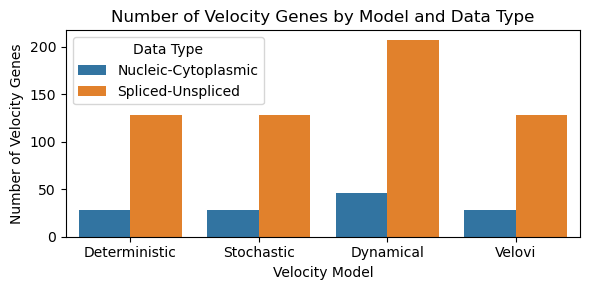

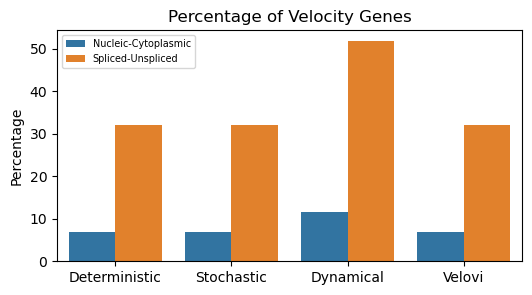

In [27]:
velocity_model_order = ['Deterministic', 'Stochastic', 'Dynamical', 'Velovi']


# Set the aesthetic style of the plots
# sns.set(style="whitegrid")

# Create a bar plot for the number of velocity genes
plt.figure(figsize=(6, 3))
sns.barplot(
    data=df_velocity_genes,
    x='velocity_model',
    y='num_velocity_genes',
    hue='data_type',
    order=velocity_model_order
    # palette='Set2'
)
plt.title('Number of Velocity Genes by Model and Data Type')
plt.xlabel('Velocity Model')
plt.ylabel('Number of Velocity Genes')
plt.legend(title='Data Type')
plt.tight_layout()
plt.show()

# Create a bar plot for the percentage of velocity genes
plt.figure(figsize=(6, 3))
sns.barplot(
    data=df_velocity_genes,
    x='velocity_model',
    y='percent_velocity_genes',
    hue='data_type',
    order=velocity_model_order
    # palette='Set2'
)
plt.title('Percentage of Velocity Genes')
plt.xlabel('')
plt.ylabel('Percentage')
plt.legend(loc='best',fontsize='x-small')
# plt.tight_layout()
plt.show()


# Velocity Correlation by gene

Checks if the velocities calculated for the same gene in different modalities are consistent. 

In [28]:
import scvelo as scv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import ma

def compute_velocity_correlations(adatas, mode='by_gene'):
    """
    Computes the correlation between velocity matrices of the same velocity type but different data types (n_c vs s_u).

    Parameters:
    - adatas (dict): Dictionary where keys are in the format 'adata_type_obs_genes_velocitytype',
                     and values are AnnData objects.
    - mode (str): 'by_gene' or 'by_cell' to specify the axis along which to compute the correlations.

    Returns:
    - correlations (dict): A dictionary with velocity types as keys and lists of correlation coefficients as values.
    """

    # Collect all unique velocity types
    velocity_types = set()
    for key in adatas.keys():
        parts = key.split('_')
        velocity_type = parts[-1]  # e.g., 'deterministic', 'stochastic', 'dynamical', 'velovi'
        velocity_types.add(velocity_type)

    correlations = {}  # Dictionary to store correlations for each velocity type
    velocity_genes = {}

    for velocity_type in velocity_types:
        print(velocity_type)
        # Find the corresponding AnnData objects for n_c and s_u
        key_n_c = None
        key_s_u = None
        for key in adatas.keys():
            if key.endswith(velocity_type):
                if '_n_c_' in key:
                    key_n_c = key
                elif '_s_u_' in key:
                    key_s_u = key
        if key_n_c and key_s_u:
            adata_n_c = adatas[key_n_c]
            adata_s_u = adatas[key_s_u]

            # Ensure that the velocity matrices are computed
            if 'velocity' not in adata_n_c.layers or 'velocity' not in adata_s_u.layers:
                print(f"Velocity not found in {key_n_c} or {key_s_u}. Skipping.")
                continue

            # Extract the velocity matrices
            velo_n_c = pd.DataFrame(
                adata_n_c.layers['velocity'], 
                index=adata_n_c.obs_names, 
                columns=adata_n_c.var_names
            )
            velo_s_u = pd.DataFrame(
                adata_s_u.layers['velocity'], 
                index=adata_s_u.obs_names, 
                columns=adata_s_u.var_names
            )

            # Ensure that the DataFrames are aligned
            # velo_n_c = velo_n_c.sort_index().sort_index(axis=1)
            # velo_s_u = velo_s_u.sort_index().sort_index(axis=1)

            # Compute correlations
            if mode == 'by_cell':
                # Compute correlation by cell (across genes)
                cross_corrs = []
                for i in velo_n_c.index:
                    v1 = velo_n_c.loc[i].values
                    v2 = velo_s_u.loc[i].values
                    # Handle NaNs
                    mask = ~np.isnan(v1) & ~np.isnan(v2)
                    if np.sum(mask) > 0:
                        corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                        cross_corrs.append(corr)
                correlations[velocity_type] = cross_corrs
            elif mode == 'by_gene':
                # Compute correlation by gene (across cells)
                cross_corrs = []
                genes = {}
                i= 0 
                for gene in velo_n_c.columns:
                    v1 = velo_n_c[gene].values
                    v2 = velo_s_u[gene].values
                    # Handle NaNs
                    mask = ~np.isnan(v1) & ~np.isnan(v2)
                    if np.sum(mask) > 0:
                        corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                        cross_corrs.append(corr)
                        genes[gene]=corr
                        i=i+1
                correlations[velocity_type] = cross_corrs
                velocity_genes[velocity_type] = genes
                 
            else:
                print(f"Unknown mode: {mode}. Use 'by_gene' or 'by_cell'.")
                return None
        else:
            print(f"Could not find matching n_c and s_u AnnData objects for velocity type {velocity_type}.")
    return correlations, velocity_genes


In [29]:
def plot_velocity_correlations(correlations):
    """
    Plots box plots of the correlations calculated for each velocity type.

    Parameters:
    - correlations (dict): Dictionary with velocity types as keys and lists of correlation coefficients as values.
    """
    # Prepare the data for plotting
    plot_data = []
    for velocity_type, corr_values in correlations.items():
        # Map velocity_type to capitalized labels
        velocity_type_map = {
            'deterministic': 'Deterministic',
            'stochastic': 'Stochastic',
            'dynamical': 'Dynamical',
            'velovi': 'VeloVI'
        }
        velocity_type_label = velocity_type_map.get(velocity_type, velocity_type.capitalize())

        df = pd.DataFrame({
            'Correlation': corr_values,
            'Velocity Type': velocity_type_label
        })
        plot_data.append(df)

    # Concatenate all DataFrames
    plot_df = pd.concat(plot_data, ignore_index=True)

    # Define the order of velocity types
    velocity_type_order = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']

    # Plotting
    plt.figure(figsize=(6, 4))
    sns.boxplot(
        x='Velocity Type',
        y='Correlation',
        data=plot_df,
        order=velocity_type_order,
        width=0.5,
        palette='Set2'
    )
    sns.stripplot(
        x='Velocity Type',
        y='Correlation',
        data=plot_df,
        order=velocity_type_order,
        color='black',
        size=2,
        jitter=True,
        alpha=0.5
    )
    plt.title('Velocity Correlation by Genes')
    plt.xlabel('')
    plt.ylabel('Correlation Coefficient')
    # plt.tight_layout()
    plt.show()


In [30]:
gene_corr, velo_genes = compute_velocity_correlations(adata_dict,mode='by_gene')

dynamical
deterministic
velovi
stochastic


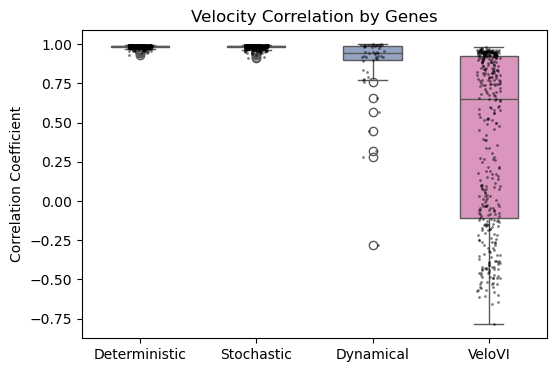

In [31]:
plot_velocity_correlations(gene_corr)

In [32]:
cell_corr, b = compute_velocity_correlations(adata_dict, mode='by_cell')

dynamical
deterministic
velovi
stochastic


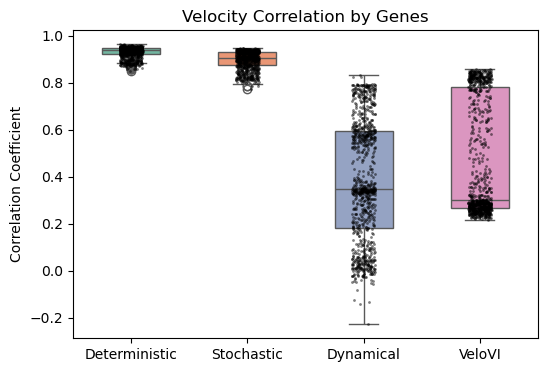

In [33]:
plot_velocity_correlations(cell_corr)

In [34]:
sorted_items = sorted(velo_genes['velovi'].items(), key=lambda item: item[1])

print(sorted_items)



[('171', -0.7856722160782279), ('53', -0.6583731151130107), ('398', -0.6419015764388107), ('318', -0.6108227191956656), ('83', -0.6081715695713749), ('260', -0.5959205439230708), ('232', -0.5791409017039826), ('179', -0.5751708281973639), ('166', -0.5689072799593127), ('47', -0.5646693152057284), ('387', -0.5567469396541098), ('390', -0.5488169942705935), ('343', -0.5484374927399311), ('306', -0.5312333609544322), ('67', -0.5292273102854435), ('209', -0.5257442515936044), ('159', -0.5232510389771203), ('26', -0.5170704188918074), ('61', -0.5158486178308248), ('150', -0.49296508220101), ('243', -0.492154605571841), ('255', -0.48923171738812404), ('60', -0.488304856608016), ('322', -0.48502176491199694), ('43', -0.48442865426348886), ('132', -0.48029887641697805), ('399', -0.4744242309553495), ('129', -0.47118483785405524), ('351', -0.4616083945742679), ('15', -0.45740383101223303), ('293', -0.45583405897557616), ('149', -0.4554815526998634), ('299', -0.441882786607572), ('330', -0.43926

- It looks like the model capture more or less the same dynamics for the genes in two modalities. Investigate lover correlations:

In [62]:
sns.set_style(style=None, rc=None)

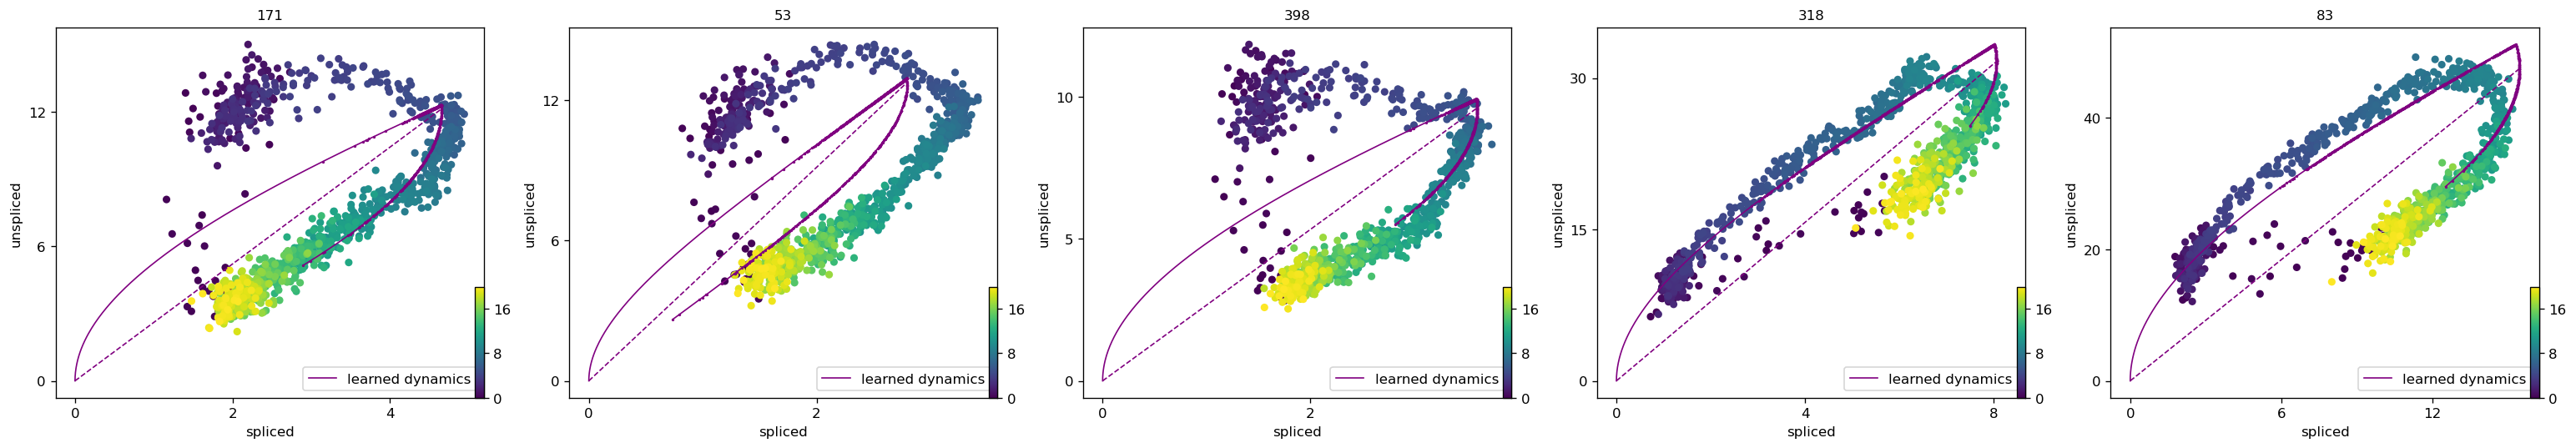

In [44]:
scv.pl.scatter(adata_dict['adata_s_u_1000obs_400genes_velovi'],color="true_t", basis=['171','53','398','318','83'], ncols=5, frameon=True,dpi=120)

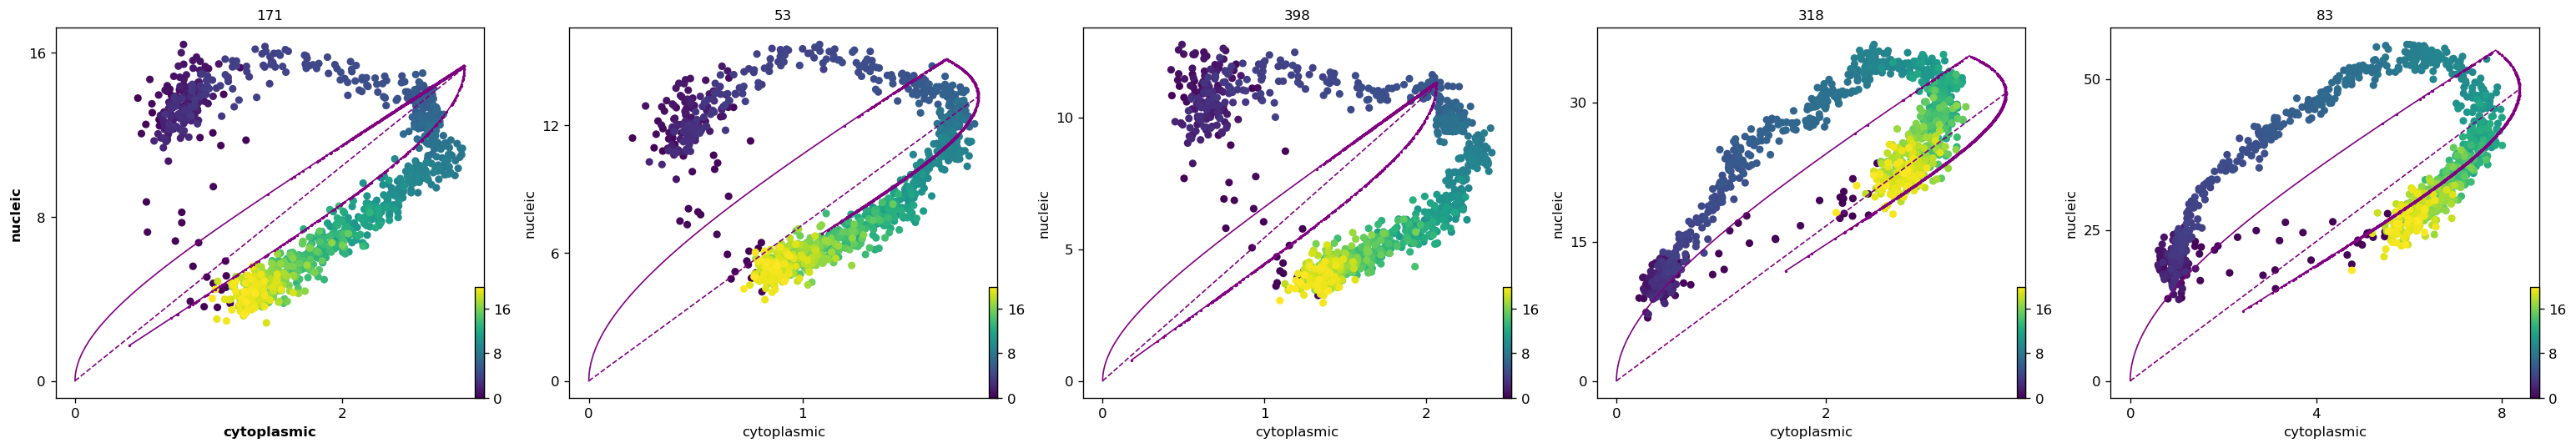

In [45]:
scv.pl.scatter(adata_dict['adata_n_c_1000obs_400genes_velovi'],color="true_t", basis=['171','53','398','318','83'], ncols=5,dpi=120,ylabel='nucleic',xlabel='cytoplasmic')

In [43]:
adata_dict['adata_s_u_1000obs_400genes_velovi'].var.iloc[171]

true_t_                 2.476509
true_alpha              7.779494
true_beta                0.11583
true_nu                 0.670283
true_gamma              0.468513
true_scaling                 1.0
n_cells                      995
velocity_gamma          2.882316
velocity_qreg_ratio     2.498334
velocity_r2             0.049771
velocity_genes              True
fit_alpha                 2.9523
fit_beta                0.234879
fit_gamma               0.612146
fit_t_                 16.300043
fit_scaling                  1.0
Name: 171, dtype: object

In [42]:
adata_dict['adata_n_c_1000obs_400genes_velovi'].var.iloc[171]

true_t_                 2.476509
true_alpha              7.779494
true_beta                0.11583
true_nu                 0.670283
true_gamma              0.468513
true_scaling                 1.0
n_cells                      995
velocity_gamma          5.265397
velocity_qreg_ratio     5.265397
velocity_r2            -0.555459
velocity_genes             False
fit_alpha               4.639441
fit_beta                0.294744
fit_gamma               1.544492
fit_t_                 12.575617
fit_scaling                  1.0
Name: 171, dtype: object

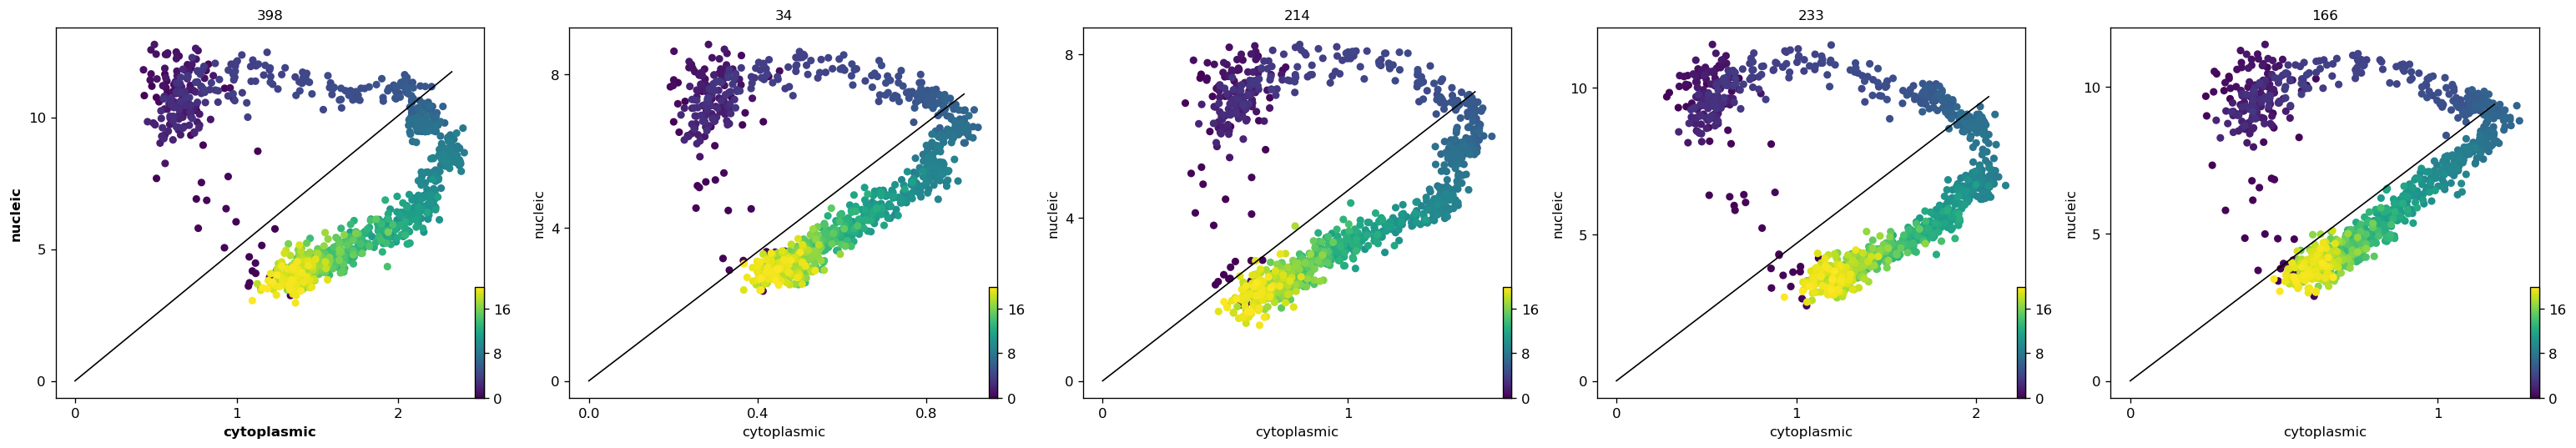

In [46]:
scv.pl.scatter(adata_dict['adata_n_c_1000obs_400genes_deterministic'],color="true_t", basis=['398','34','214','233','166'], ncols=5,dpi=120,ylabel='nucleic',xlabel='cytoplasmic')

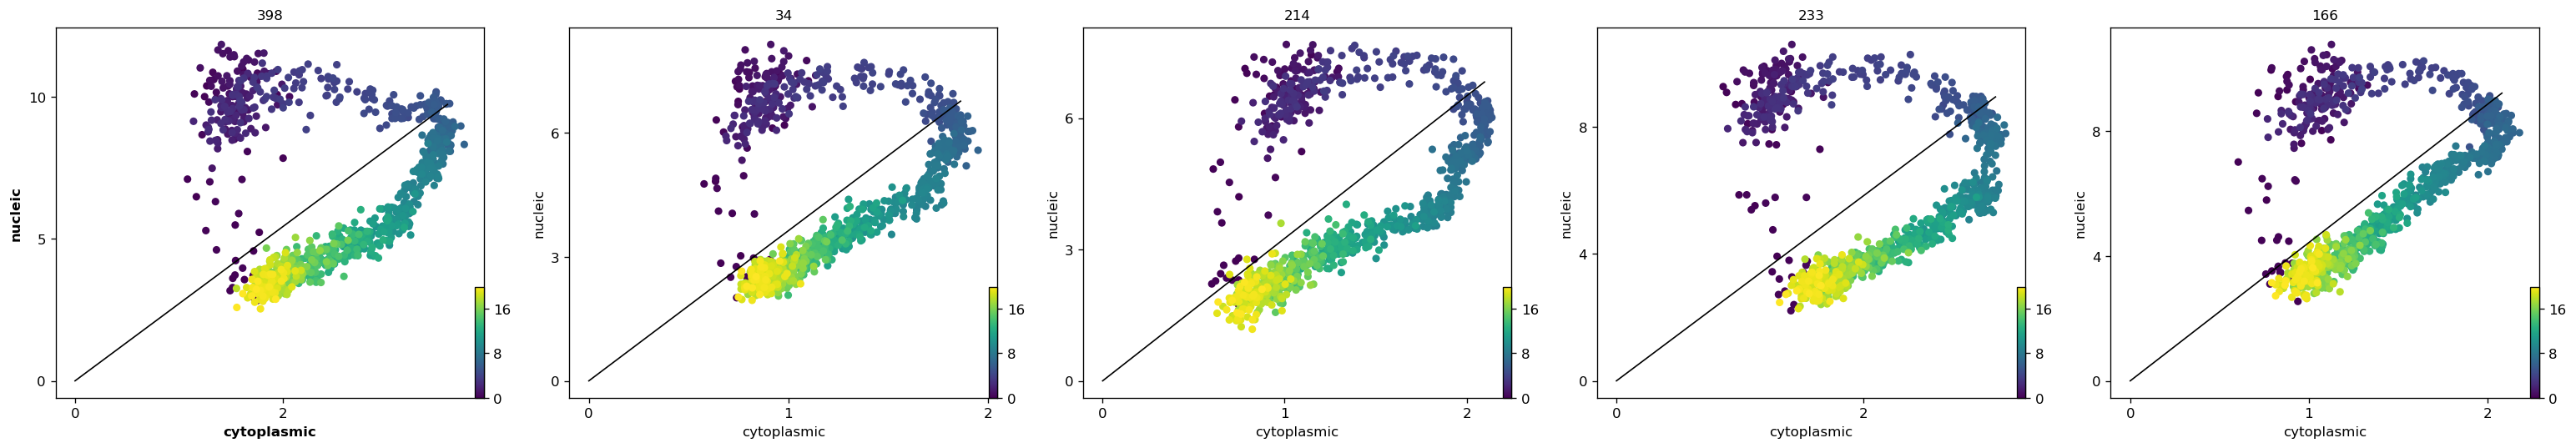

In [47]:
scv.pl.scatter(adata_dict['adata_s_u_1000obs_400genes_deterministic'],color="true_t", basis=['398','34','214','233','166'], ncols=5,dpi=120,ylabel='nucleic',xlabel='cytoplasmic')

# Check the important genes 

In [49]:
for key , adata in adata_dict.items():
    scv.tl.rank_velocity_genes(adata,groupby='leiden',min_corr=.3)

ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
   

In [50]:
dfs = scv.get_df(adata_dict['adata_s_u_1000obs_400genes_velovi'].uns['rank_velocity_genes']['names'])
dfs.head(5)

,0,1,2,3,4,5
0,198,260,92,149,149,262
1,99,232,99,273,164,166
2,95,298,75,164,209,312
3,75,20,198,209,273,345
4,230,103,95,300,210,214


In [51]:
dfn = scv.get_df(adata_dict['adata_n_c_1000obs_400genes_velovi'].uns['rank_velocity_genes']['names'])
dfn.head(5)

,0,1,2,3,4,5
0,228,164,318,300,300,300
1,277,273,10,52,52,273
2,149,276,52,122,318,193
3,318,275,300,149,149,164
4,10,89,277,19,10,52


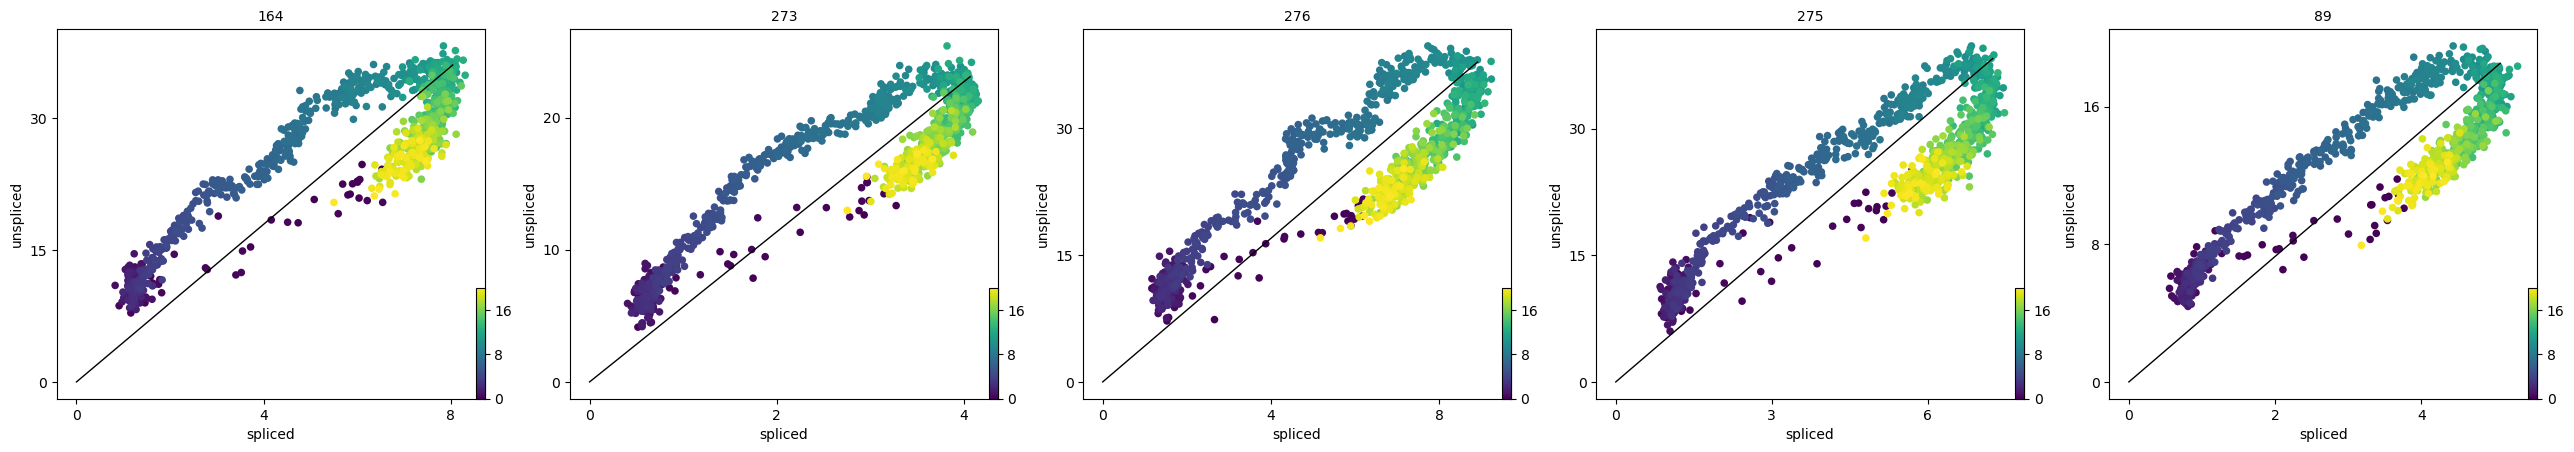

In [ ]:
scv.pl.scatter(adata_dict['adata_s_u_1000obs_400genes_deterministic'], dfn.head()['1'][:5], color= 'true_t')

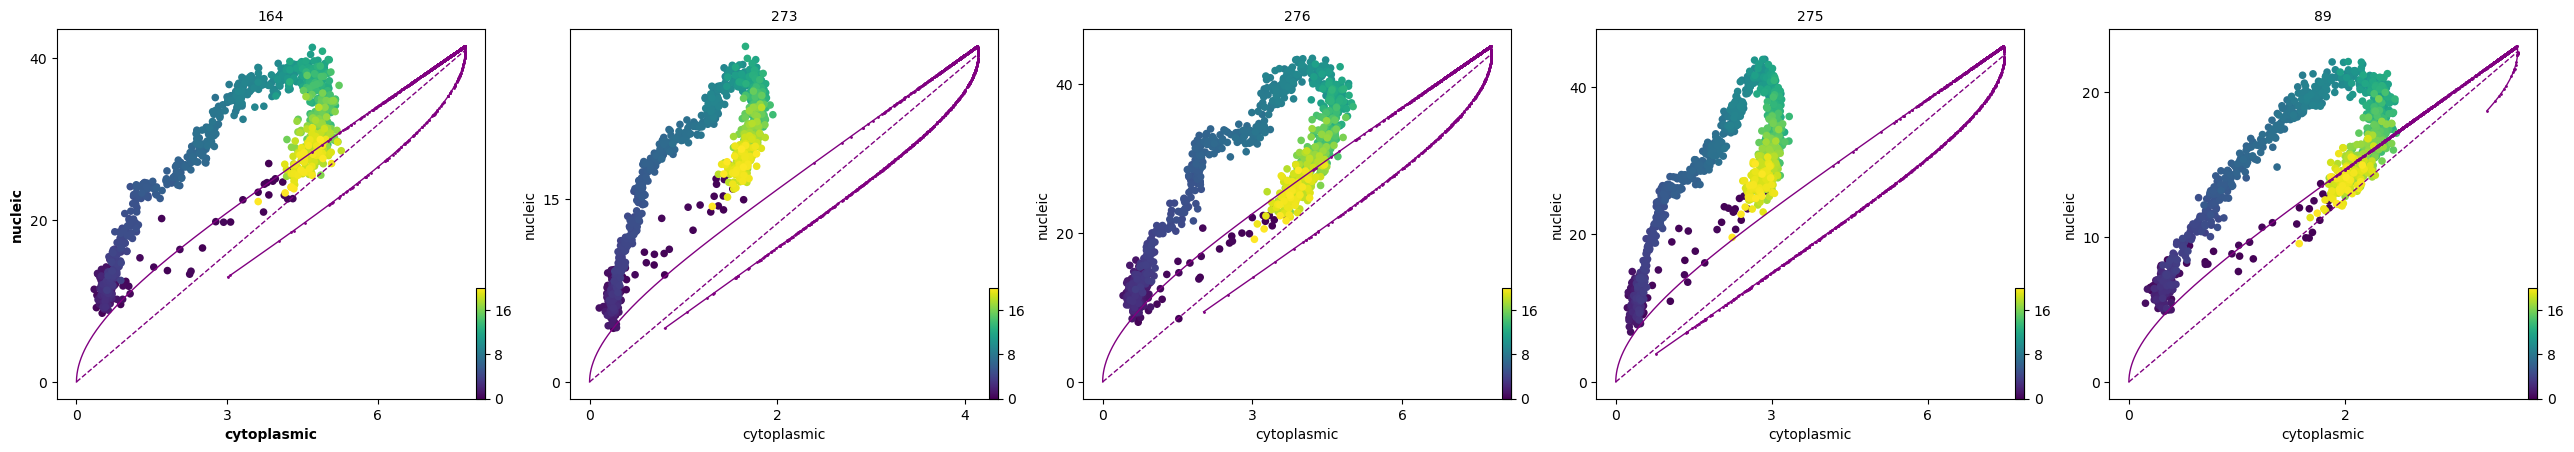

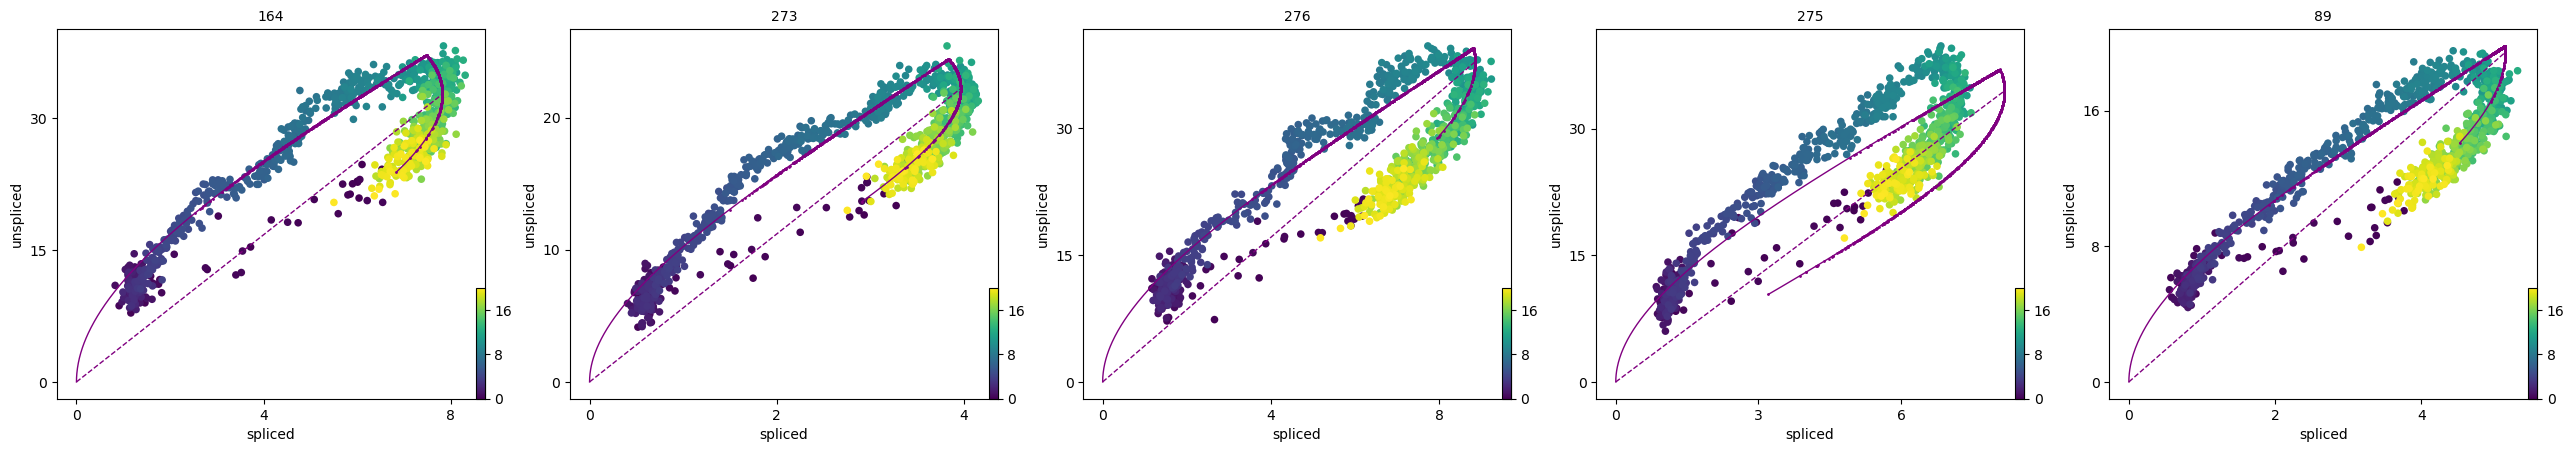

In [53]:
scv.pl.scatter(adata_dict['adata_n_c_1000obs_400genes_velovi'], dfn.head()['1'][:5], ylabel='nucleic',xlabel='cytoplasmic' ,color='true_t')
scv.pl.scatter(adata_dict['adata_s_u_1000obs_400genes_velovi'], dfn.head()['1'][:5], color= 'true_t')

In [ ]:
adata_dict_s_u = {k:v.copy() for k,v in adata_dict.items() if 's_u_' in k}

In [54]:
corr_by_cell = velocity_mean_correlation(adata_dict,mode='by_cell')
corr_by_gene = velocity_mean_correlation(adata_dict,mode='by_gene')

In [55]:
name_mapping = {}

# Define data type mapping
data_type_map = {
    'n_c': 'in situ',
    's_u': 'splicing'
}

# Loop over each name in the index (and columns)
for name in corr_by_cell.index:
    parts = name.split('_')
    # Extract data type (e.g., 'n_c' or 's_u')
    data_type = parts[1] + '_' + parts[2]
    data_type_label = data_type_map.get(data_type, data_type)
    
    # Extract velocity model (e.g., 'deterministic', 'stochastic', etc.)
    velocity_model = parts[5]
    # Capitalize the velocity model name
    velocity_model_label = velocity_model.capitalize()
    
    # Combine to form the new label
    new_label = f"{velocity_model_label} {data_type_label}"
    
    # Add to the mapping
    name_mapping[name] = new_label



In [56]:
# Rename the index and columns using the mapping
corr_by_cell = corr_by_cell.rename(index=name_mapping, columns=name_mapping)
corr_by_gene = corr_by_gene.rename(index=name_mapping, columns=name_mapping)

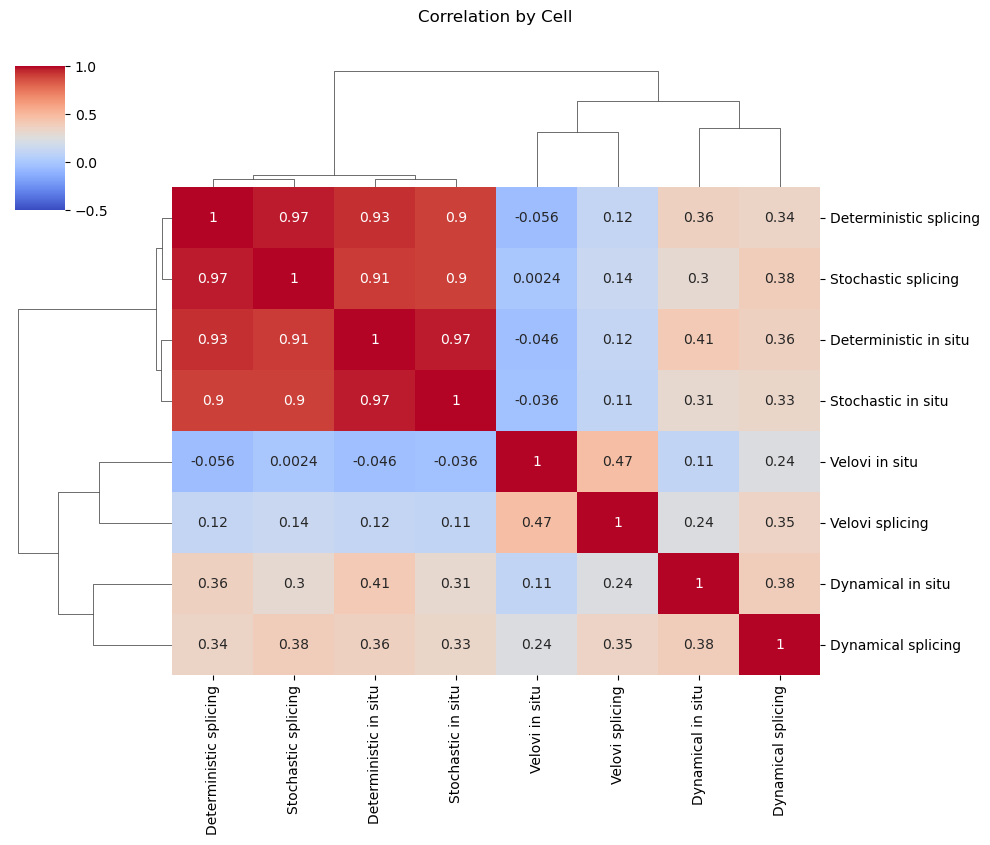

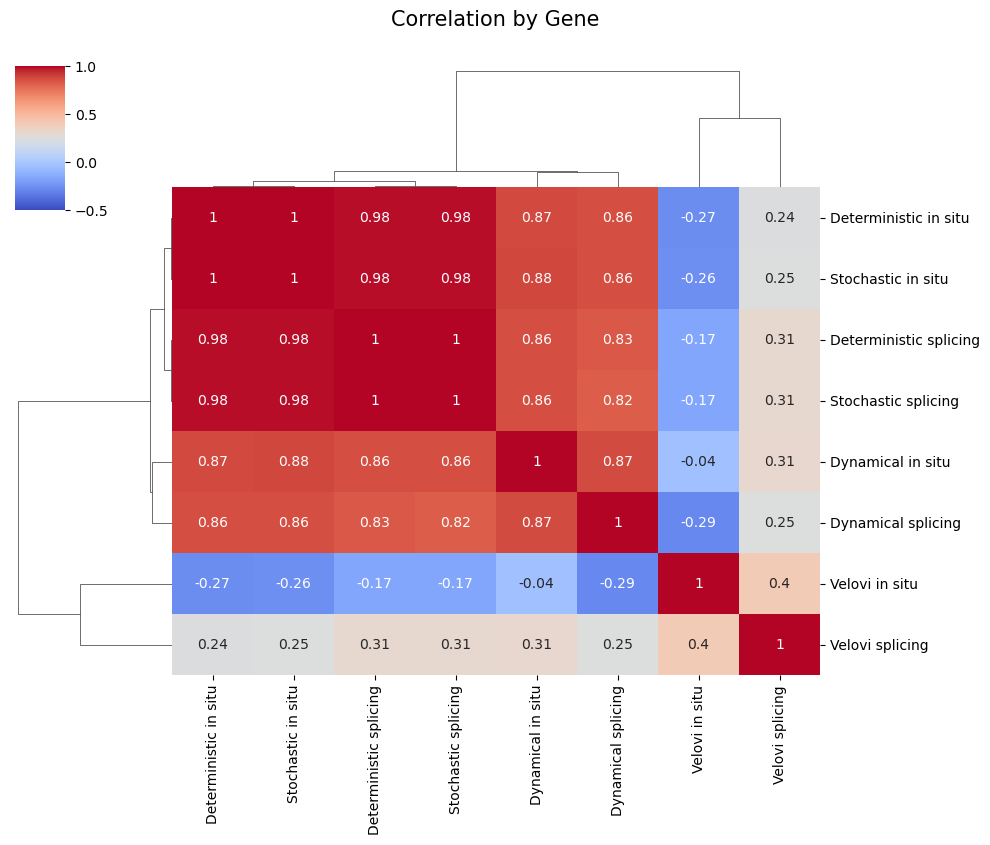

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# First clustermap for corr_by_cell
g1 = sns.clustermap(corr_by_cell, cmap='coolwarm', annot=True, figsize=(10, 8), vmin=-0.5, vmax=1)

# Add title to the first clustermap
g1.fig.suptitle('Correlation by Cell', y=1.05)


# Show the plot
plt.show()

# Second clustermap for corr_by_gene
g2 = sns.clustermap(corr_by_gene, cmap='coolwarm', annot=True, figsize=(10, 8), vmin=-0.5, vmax=1)

# Add title to the second clustermap
g2.fig.suptitle('Correlation by Gene', y=1.05,fontsize =15)


# Show the plot
plt.show()


# True Velocity cosine similarity 

In [37]:
from sklearn.metrics.pairwise import cosine_similarity
def compute_cosine_similarity(true_velocities, estimated_velocities):
    n_genes = true_velocities.shape[1]
    cosine_similarities = np.zeros(n_genes)

    for i in range(n_genes):
        true_v = true_velocities[:, i]
        est_v = estimated_velocities[:, i]

        true_v = true_v.reshape(1, -1)
        est_v = est_v.reshape(1, -1)

        cos_sim = cosine_similarity(true_v, est_v)[0][0]

        cosine_similarities[i] = cos_sim

    return cosine_similarities

In [40]:
true_velocity = adata_dict['adata_s_u_1000obs_400genes_velovi'].layers['velocity']
velocity = adata_dict['adata_s_u_1000obs_400genes_velovi'].layers['true_velocity']
# velocity_filtered = velocity[:, ~np.isnan(velocity).any(axis=0)]
# true_velocity_filtered =  true_velocity[:, ~np.isnan(velocity).any(axis=0)]

# velocity_filtered.shape

In [41]:
compute_cosine_similarity( true_velocity, velocity).mean()

0.37052712215052763

In [46]:
true_velocity = adata_dict['adata_n_c_1000obs_400genes_dynamical'].layers['true_velocity']
velocity = adata_dict['adata_n_c_1000obs_400genes_dynamical'].layers['velocity']
velocity_filtered = velocity[:, ~np.isnan(velocity).any(axis=0)]
true_velocity_filtered =  true_velocity[:, ~np.isnan(velocity).any(axis=0)]
compute_cosine_similarity( velocity_filtered, true_velocity_filtered).mean()

0.3182795755225731

In [58]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Your sorted data arrays
def plot_gene_counts(n_obs: None, n_var : None, gene : 0):
    adata = adata_dict[f'adata_n_c_{n_obs}obs_{n_var}genes_deterministic']
    unspliced = adata.layers['unspliced'][:,gene]- adata.layers['spliced_nuc'][:,gene] 
    spliced_nuc = adata.layers['spliced_nuc'][:,gene]
    spliced_cyto = adata.layers['spliced'][:,gene]

    t_max = adata.obs['true_t'].max()

    # Assuming the x-values are indices or known values
    x_values = np.arange(len(unspliced))
    scaling_factor = t_max / n_obs
    x_values_scaled = x_values * scaling_factor

    # Define a function for moving average smoothing
    def moving_average(y, window_size):
        return np.convolve(y, np.ones(window_size)/window_size, mode='valid')

    # Set the window size for smoothing
    window_size = 15  # Adjust the window size as needed

    # Calculate the moving averages for each dataset
    smooth_data1 = moving_average(unspliced, window_size)
    smooth_data2 = moving_average(spliced_nuc, window_size)
    smooth_data3 = moving_average(spliced_cyto, window_size)

    smooth_x_values = x_values[:len(smooth_data1)] + (window_size // 2)
    smooth_x_values_scaled = smooth_x_values * scaling_factor

    # Plot the smooth lines for each dataset using scaled x-values
    plt.plot(smooth_x_values_scaled, smooth_data1, color='blue', linewidth=2, label='unspliced')
    plt.plot(smooth_x_values_scaled, smooth_data2, color='red', linewidth=2, label='spliced nucleic')
    plt.plot(smooth_x_values_scaled, smooth_data3, color='green', linewidth=2, label='spliced cytoplasmic')


    true_t = adata.var['true_t_'][gene] 


    # Draw the vertical line using the scaled x-value
    plt.axvline(x=true_t, color='black', linestyle='--', linewidth=1, label='switch time')

    # Add labels and title
    plt.xlabel('Time')
    plt.ylabel('Abundances')
    plt.title('mRNA abundances change over time')
    plt.legend(loc = 'upper right',fontsize = 8)
    plt.grid(True)

    # Display the plot
    plt.show()


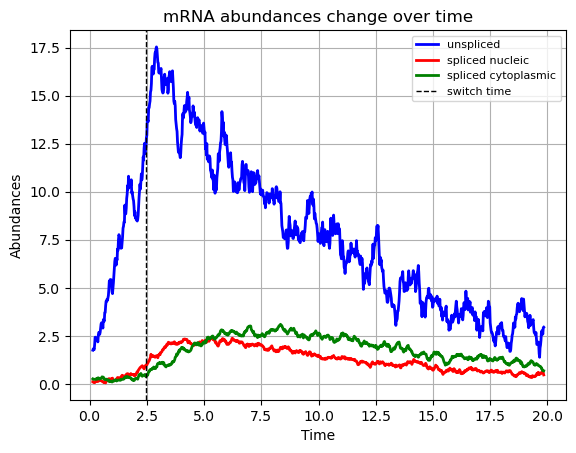

In [59]:
plot_gene_counts(n_obs=1000,n_var=400,gene=171)

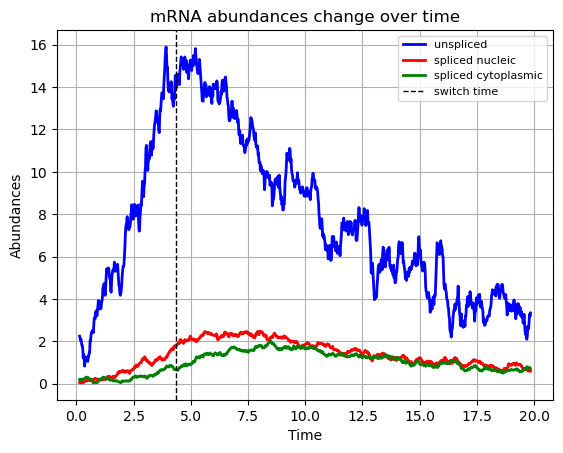

In [86]:
plot_gene_counts(n_obs=1000,n_var=400,gene=30)

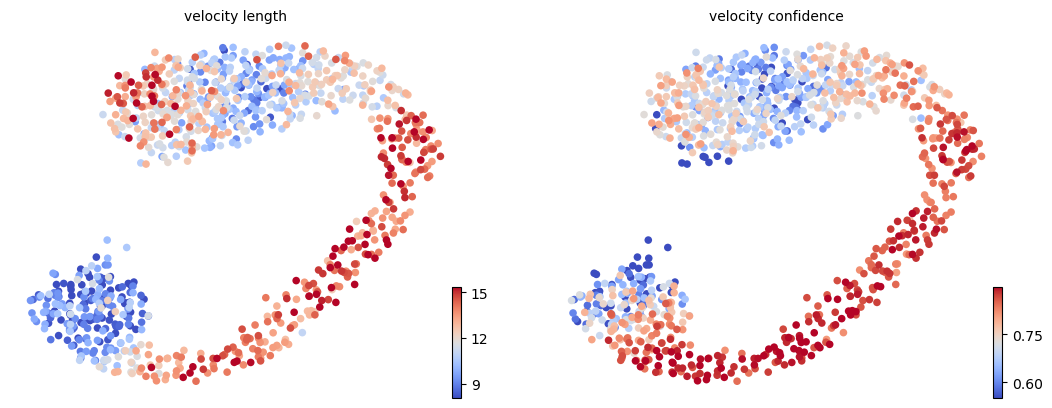

In [88]:
# scv.tl.velocity_confidence(adata_dict['adata_n_c_1000obs_400genes_deterministic'])
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter((adata_dict['adata_n_c_1000obs_400genes_deterministic']), c=keys, cmap='coolwarm', perc=[5, 95])

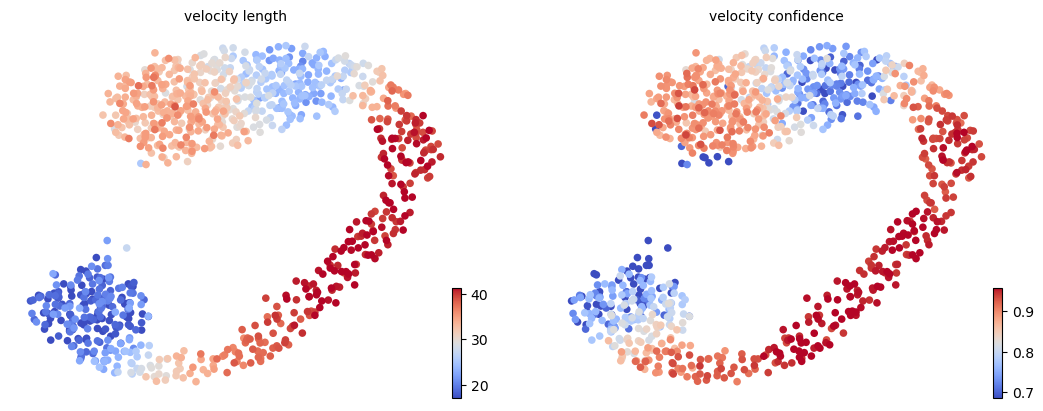

In [89]:
scv.pl.scatter((adata_dict['adata_s_u_1000obs_400genes_deterministic']), c=keys, cmap='coolwarm', perc=[5, 95])

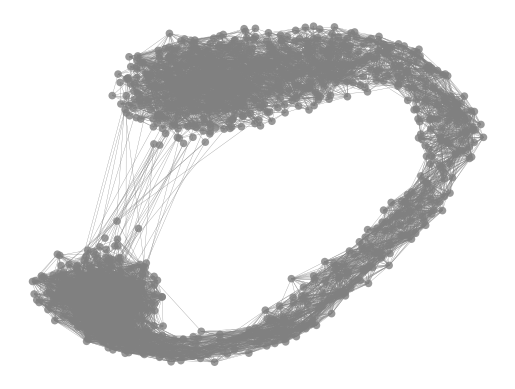

In [ ]:
scv.pl.velocity_graph

# New Metric - Steady State correlation 

In [65]:
adata_dict['adata_n_c_1000obs_400genes_velovi']

AnnData object with n_obs × n_vars = 1000 × 400
    obs: 'true_t', 'n_counts', 'leiden', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'spearmans_score', 'velocity_score'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'rank_velocity_genes'
    obsm: 'X_pca', 'X_umap', 'velocity_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'fit_t', 'latent_time_velovi', 'spliced', 'spliced_cyt', 'spliced_nuc', 'true_velocity', 'unspliced', 'variance_velocity', 'velocity'
    obsp: 'connectivities', 'distances'

In [8]:
for key, adata in adata_dict.items():
    true_beta = adata.var['true_beta']
    true_nu = adata.var['true_nu']
    true_gamma = adata.var['true_gamma']
    if 's_u' in key:
        true_ratio = (1/true_beta )* (1/((1/true_gamma)+(1/true_nu)))
    else:
        true_ratio = true_gamma*((1/true_nu)+(1/true_beta))
    adata.var['true_ratio'] = true_ratio
        
         

In [67]:
adata_dict['adata_n_c_1000obs_400genes_deterministic'].var['true_ratio']

0      4.728106
1      4.474766
2      4.362445
3      6.369610
4      8.099613
         ...   
395    5.477018
396    9.067061
397    4.221513
398    4.125995
399    3.904738
Name: true_ratio, Length: 400, dtype: float64

In [68]:
adata_dict['adata_n_c_1000obs_400genes_deterministic'].var['velocity_gamma']

0      5.651716
1      5.637168
2      5.362559
3      8.131578
4      9.369523
         ...   
395    5.983964
396    9.678447
397    5.556365
398    5.029573
399    4.220106
Name: velocity_gamma, Length: 400, dtype: float32

In [69]:
c = adata_dict['adata_n_c_1000obs_400genes_velovi'].var['fit_gamma']/ adata_dict['adata_n_c_1000obs_400genes_velovi'].var['fit_beta']

In [70]:
d = adata_dict['adata_n_c_1000obs_400genes_dynamical'].var['fit_gamma']/ adata_dict['adata_n_c_1000obs_400genes_dynamical'].var['fit_beta']

In [76]:
mask =  ~np.isnan(d)

In [77]:
d[mask]

0      61.136025
1      47.887986
5       8.178455
7      42.468814
8      22.337856
         ...    
382    23.354697
384    29.548226
385    13.575985
393    16.577279
395    21.854842
Length: 134, dtype: float64

In [78]:
b[mask]

0      68.378533
1      55.064630
5      10.725137
7      37.379021
8      27.171683
         ...    
382    25.922860
384    33.876261
385    16.706914
393    18.771396
395    27.171391
Name: true_ratio, Length: 134, dtype: float64

In [13]:
from scipy.stats import pearsonr

In [72]:
a = adata_dict['adata_n_c_1000obs_400genes_deterministic'].var['velocity_gamma']
b =  adata_dict['adata_n_c_1000obs_400genes_deterministic'].var['true_ratio']

In [80]:
a = pearsonr(a,c)

In [85]:
adata_dict['adata_s_u_1000obs_400genes_velovi'].var

,true_t_,true_alpha,true_beta,true_nu,true_gamma,true_scaling,n_cells,velocity_gamma,velocity_qreg_ratio,velocity_r2,velocity_genes,fit_alpha,fit_beta,fit_gamma,fit_t_,fit_scaling,spearmans_score,velocity_score,true_ratio
0,6.922694,3.731545,0.124457,0.611503,0.488934,1.0,993,2.740378,2.740378,-0.199559,False,3.148535,0.167532,0.430193,16.663183,1.0,0.626645,0,2.183057
1,8.436637,5.562974,0.102173,0.866915,0.408998,1.0,998,3.373245,3.373245,-0.485585,False,6.362784,0.174966,0.545039,18.232042,1.0,0.659074,0,2.719811
2,7.421023,5.662568,0.117631,0.631976,0.432631,1.0,994,2.811386,2.811386,-0.325036,False,4.312480,0.156877,0.376489,16.403736,1.0,0.584101,0,2.183273
3,6.901749,6.046986,0.111948,0.568219,0.595703,1.0,995,3.094150,3.094150,-0.124300,False,5.280880,0.182225,0.526674,16.612928,1.0,0.621564,0,2.597796
4,5.800474,4.996347,0.101176,0.669677,0.711926,1.0,992,4.040390,3.825349,0.161220,True,5.787944,0.286540,1.101482,12.233465,1.0,0.657244,18,3.410674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,10.625713,4.794432,0.086493,0.657314,0.418639,1.0,991,3.223335,3.299670,0.322181,True,8.613301,0.283878,0.970313,15.671157,1.0,0.723843,41,2.956898
396,5.195763,4.696223,0.092084,0.456479,0.694774,1.0,995,3.689958,3.689958,-0.553389,False,4.185811,0.227858,0.850815,12.032953,1.0,0.519295,0,2.991652
397,5.195763,5.565128,0.112275,0.993042,0.425825,1.0,996,3.560449,3.560449,-0.562330,False,5.244513,0.253455,0.921542,13.005723,1.0,0.436659,0,2.654453
398,2.144764,6.761840,0.099378,0.701161,0.359133,1.0,999,2.712937,2.712937,-0.275087,False,1.854154,0.177120,0.471865,16.682798,1.0,0.157212,0,2.389766


In [81]:
a[0]

0.8172770116456061

In [79]:
corr = pearsonr(d[mask],b[mask])

In [79]:
a = adata_dict['adata_n_c_1000obs_400genes_velovi'].var['true_ratio']
b = adata_dict['adata_n_c_1000obs_400genes_velovi'].var['fit_gamma']

In [52]:
cor = pearsonr(a,b)

In [53]:
cor[0]

0.9933581197505532

In [5]:
read_dictionary = np.load('data/vae/beta_small_22.npy',allow_pickle='TRUE').item()
vae = read_dictionary['adata_n_c_1000obs_400genes_velovi']

In [22]:
a = adata_dict['adata_n_c_1000obs_400genes_velovi'].var['true_ratio']
b = adata_dict['adata_n_c_1000obs_400genes_velovi'].var['fit_gamma']/ adata_dict['adata_n_c_1000obs_400genes_velovi'].var['fit_beta']
c= vae.get_rates()["gamma"]/vae.get_rates()["beta"]

In [6]:
a = vae.get_expression_fit(n_samples=20)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [11]:
from scvelo.plotting.simulation import compute_dynamics

In [ ]:
def compute_mse(ms, mu, velovi_fit_s, velovi_fit_u, scvelo_fit_s, scvelo_fit_u):
    velovi_mse_s = np.mean((velovi_fit_s - ms) ** 2, axis=0)
    velovi_mse_u = np.mean((velovi_fit_u - mu) ** 2, axis=0)
    scvelo_mse_s = np.mean((scvelo_fit_s - ms) ** 2, axis=0)
    scvelo_mse_u = np.mean((scvelo_fit_u - mu) ** 2, axis=0)

    mse_df = pd.DataFrame()
    s = np.log10(scvelo_mse_s / velovi_mse_s)
    u = np.log10(scvelo_mse_u / velovi_mse_u)

    mse_df["log10 MSE ratio"] = np.concatenate([s, u]).ravel()
    mse_df["Feature"] = ["Spliced"] * len(s) + ["Unspliced"] * len(u)
    return mse_df

In [10]:
a

(            0         1         2         3         4         5         6  \
 0    1.018790  2.245604  1.122612  1.427079  1.054731  1.160735  0.939121   
 1    1.043600  1.918128  1.434051  1.544017  1.069417  1.515597  0.813130   
 2    1.159021  2.557887  2.209547  1.714944  1.083391  1.681818  0.900853   
 3    0.992802  2.701900  2.123129  1.769971  1.109332  1.496851  0.895856   
 4    0.817329  2.634692  1.300077  1.496045  0.959941  1.700217  0.854684   
 ..        ...       ...       ...       ...       ...       ...       ...   
 995  0.980432  2.502702  1.683807  1.718813  1.174341  1.834920  1.045013   
 996  0.758950  1.689703  1.435749  1.286147  0.737409  1.060420  0.749209   
 997  1.203107  1.996319  1.517084  1.450361  1.242979  1.434609  0.930334   
 998  0.943411  2.391778  1.117936  1.537077  0.950453  1.538468  0.816112   
 999  0.922432  2.163185  1.636188  1.588331  1.087808  1.166198  0.953069   
 
             7         8         9  ...       390       391   

In [26]:
pearsonr(a,c)[0]

0.8172770092140673

In [64]:
adata_dict['adata_n_c_1000obs_400genes_velovi'].var['true_t_']

0      13.021076
1      16.471521
2      14.149126
3      12.935907
4      10.384042
         ...    
395    21.480076
396     8.948940
397     8.967929
398     1.775748
399     5.373863
Name: true_t_, Length: 400, dtype: float64

In [67]:
adata_dict['adata_n_c_1000obs_400genes_deterministic'].var

,true_t_,true_alpha,true_beta,true_nu,true_gamma,true_scaling,n_cells,velocity_gamma,velocity_qreg_ratio,velocity_r2,velocity_genes,spearmans_score,velocity_score,true_ratio
0,13.021076,7.120129,0.010486,0.196114,0.124699,1.0,989,17.104685,17.104685,-1.431322,False,0.725624,0,12.527403
1,16.471521,4.227770,0.040734,0.474327,0.110565,1.0,996,3.586494,3.586494,-2.107745,False,0.595651,0,2.947392
2,14.149126,6.461462,0.016126,0.301854,0.714361,1.0,989,49.978191,49.978191,0.086473,True,0.731753,0,46.665532
3,12.935907,2.289417,0.011786,0.140294,0.428503,1.0,990,44.658466,44.658466,-1.440200,False,0.676663,0,39.410465
4,10.384042,3.259717,0.034666,0.284671,0.136308,1.0,990,5.210393,5.210393,-6.317648,False,0.126271,0,4.410795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,21.480076,3.018309,0.017038,0.459451,0.308984,1.0,988,21.254807,21.254807,0.661862,True,0.929235,-24,18.807559
396,8.948940,4.178601,0.010481,1.554791,0.278207,1.0,994,27.755680,27.755680,-1.933546,False,0.638996,0,26.722001
397,8.967929,3.713329,0.043973,0.252975,0.180025,1.0,995,5.245944,5.245944,-6.511124,False,0.000000,0,4.805626
398,1.775748,6.235544,0.019720,0.440899,0.511269,1.0,999,28.726479,28.726479,-0.895630,False,0.037686,0,27.085497


In [62]:
adata_dict['adata_n_c_1000obs_400genes_velovi'].layers['fit_t'][0]

array([25.08637  , 15.050941 , 24.791025 , 16.53758  , 13.690966 ,
       21.040262 , 20.232342 ,  6.7385035, 19.47941  , 15.952738 ,
       18.621778 , 12.43071  , 24.843765 , 20.899052 , 21.712381 ,
       13.015106 , 18.786219 , 22.985514 , 14.51099  , 19.775389 ,
       25.788662 , 24.821682 , 21.025146 , 18.794443 , 21.499727 ,
       17.262733 , 21.211819 , 26.832972 , 24.57118  ,  9.189996 ,
       21.572199 , 22.246758 , 21.718096 , 18.23778  , 24.659721 ,
       20.436848 , 18.466461 , 13.175288 , 20.782642 , 18.080032 ,
       23.757072 , 22.017817 , 19.94741  , 16.801464 , 21.51821  ,
       25.461466 ,  7.800199 , 22.719809 , 22.691055 ,  5.5419507,
       18.117435 , 15.9818735, 27.160753 , 25.328888 , 19.405434 ,
       26.253187 , 19.98789  , 23.528759 , 19.168133 , 15.208466 ,
       11.712127 , 21.368217 , 17.279486 , 17.29814  , 14.602783 ,
       20.831198 , 18.558979 , 17.28994  , 17.822657 , 16.54776  ,
       17.278751 , 23.005754 , 25.252537 , 13.214329 , 19.3543